##Transfer Learning

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# Hyperparameters
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001

# Image Transformations
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# Dataset
train_dataset = datasets.CIFAR10(
    "./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    "./data",
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Load Pretrained ResNet18
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# Freeze Backbone
for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features

model.fc = nn.Linear(num_features,10)
model = model.to(device)

# Loss
criterion = nn.CrossEntropyLoss()

# Only optimize the new classifier
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=LEARNING_RATE
)

# Training
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(
        f"Epoch {epoch+1}/{EPOCHS}"
        f" Loss={running_loss/len(train_loader):.4f}"
    )

# Evaluation
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs,1)
        total += labels.size(0)
        correct += (predicted==labels).sum().item()
accuracy = 100 * correct / total
print(f"\nTest Accuracy: {accuracy:.2f}%")

# Save Model
torch.save(model.state_dict(),"resnet18_cifar10.pth")
print("Model Saved!")

Using Device: cuda


100%|██████████| 170M/170M [1:03:48<00:00, 44.5kB/s]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 121MB/s]


Epoch 1/10 Loss=0.8223
Epoch 2/10 Loss=0.6142
Epoch 3/10 Loss=0.5905
Epoch 4/10 Loss=0.5792
Epoch 5/10 Loss=0.5769
Epoch 6/10 Loss=0.5653
Epoch 7/10 Loss=0.5599
Epoch 8/10 Loss=0.5572
Epoch 9/10 Loss=0.5544
Epoch 10/10 Loss=0.5575

Test Accuracy: 80.27%
Model Saved!


##Fine Tuned Transfer Learning

Using Device: cuda
Epoch 1/10 | Loss: 0.4180 | Accuracy: 85.96%
Epoch 2/10 | Loss: 0.2179 | Accuracy: 92.48%
Epoch 3/10 | Loss: 0.1575 | Accuracy: 94.60%
Epoch 4/10 | Loss: 0.1219 | Accuracy: 95.83%
Epoch 5/10 | Loss: 0.0933 | Accuracy: 96.81%
Epoch 6/10 | Loss: 0.0760 | Accuracy: 97.50%
Epoch 7/10 | Loss: 0.0644 | Accuracy: 97.81%
Epoch 8/10 | Loss: 0.0501 | Accuracy: 98.33%
Epoch 9/10 | Loss: 0.0472 | Accuracy: 98.38%
Epoch 10/10 | Loss: 0.0399 | Accuracy: 98.65%
Test Accuracy : 92.66%
Final Model Saved!


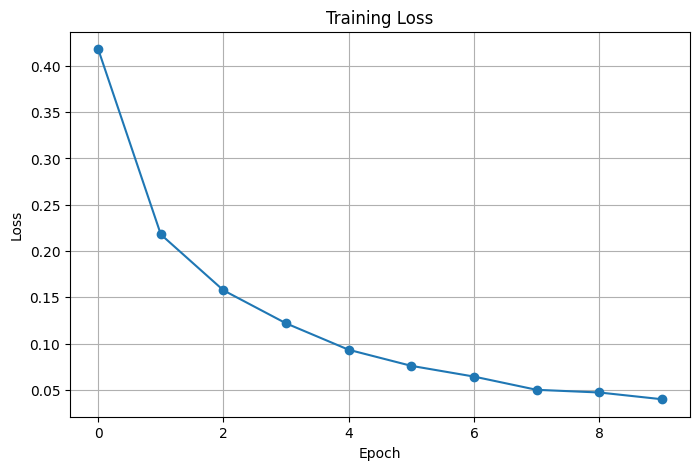

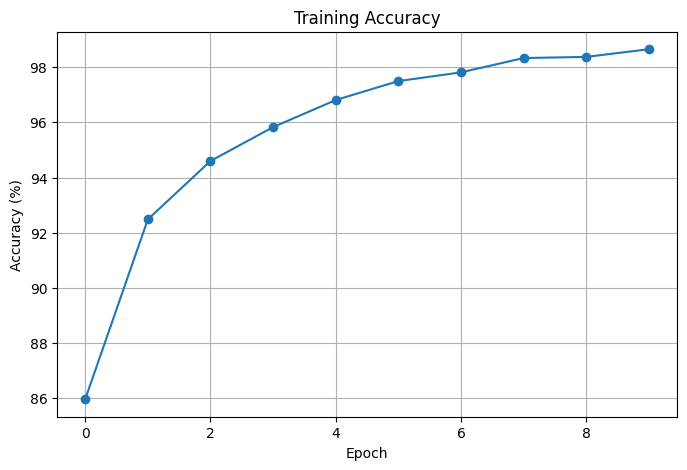

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# Hyperparameters
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 1e-4


# Data Transformations

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=8),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Dataset
train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Load Pretrained ResNet18
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False


# Unfreeze Layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace FC Layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

model = model.to(device)

# Loss Function
criterion = nn.CrossEntropyLoss()


# Optimizer
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE
)

# Lists for Graphs
train_losses = []
train_accuracies = []
best_accuracy = 0

# Training
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)
    print(
        f"Epoch {epoch+1}/{EPOCHS}"
        f" | Loss: {epoch_loss:.4f}"
        f" | Accuracy: {epoch_accuracy:.2f}%"
    )

    # Save Best Model
    if epoch_accuracy > best_accuracy:
        best_accuracy = epoch_accuracy
        torch.save(model.state_dict(), "best_resnet18_finetuned.pth")

# Testing
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
test_accuracy = 100 * correct / total

print(f"Test Accuracy : {test_accuracy:.2f}%")

# Save Final Model
torch.save(model.state_dict(), "resnet18_finetuned_final.pth")
print("Final Model Saved!")

# Plot Training Loss
plt.figure(figsize=(8,5))
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.savefig("finetune_loss.png")
plt.show()

# Plot Training Accuracy
plt.figure(figsize=(8,5))
plt.plot(train_accuracies, marker='o')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.savefig("finetune_accuracy.png")
plt.show()